In [26]:
#Firstly I impport all relevant modules
#Step1:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

file_path = '/home/asabele/Downloads/Documents/My Data Science Practise/car_data.csv'

df_clean = pd.read_csv(file_path)

# If the first column is unnamed or just an index, let's ensure 'Sales' is available
if 'Unnamed: 0' in df_clean.columns:
    df_clean = df_clean.rename(columns={'Unnamed: 0': 'Index'})

# 2. Clean and Check
df_clean = df_clean.dropna()

print("Cleaned Dataset Shape:", df_clean.shape)
print("First 5 rows:")
print(df_clean.head())
print("Statistical Summary:")
print(df_clean.describe())
print("Missing Values:")
print(df_clean.isnull().sum())



Cleaned Dataset Shape: (301, 9)
First 5 rows:
  Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Selling_type Transmission  Owner  
0       Dealer       Manual      0  
1       Dealer       Manual      0  
2       Dealer       Manual      0  
3       Dealer       Manual      0  
4       Dealer       Manual      0  
Statistical Summary:
              Year  Selling_Price  Present_Price     Driven_kms       Owner
count   301.000000     301.000000     301.000000     301.000000  301.000000
mean   2013.627907       4.661296       7.628472   36947.205980    0.043189
std       2.891554       5.082812       8.642584  

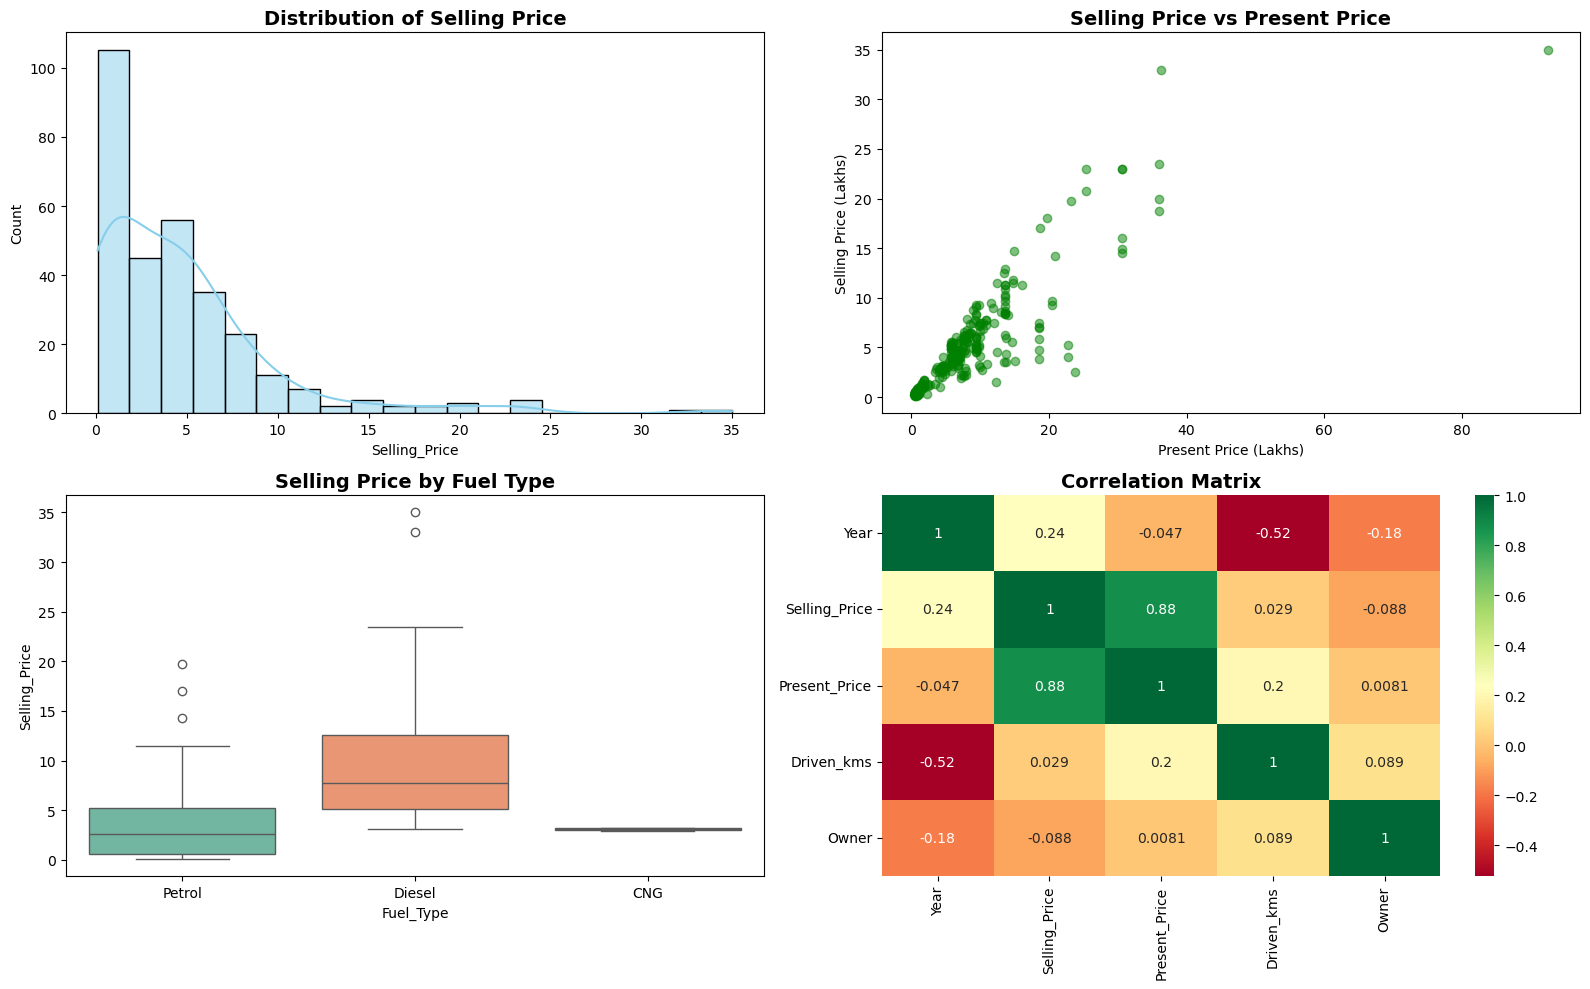

In [27]:
# Create a 2x2 grid for Car Data
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Distribution of Selling Price
sns.histplot(df_clean['Selling_Price'], bins=20, kde=True, color='skyblue', ax=axes[0, 0])
axes[0, 0].set_title('Distribution of Selling Price', fontsize=14, fontweight='bold')

# 2. Selling Price vs Present Price (Checking for linear relationship)
axes[0, 1].scatter(df_clean['Present_Price'], df_clean['Selling_Price'], alpha=0.5, color='green')
axes[0, 1].set_title('Selling Price vs Present Price', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Present Price (Lakhs)')
axes[0, 1].set_ylabel('Selling Price (Lakhs)')

# 3. Fuel Type vs Selling Price (Categorical Analysis)
sns.boxplot(x='Fuel_Type', y='Selling_Price', data=df_clean, ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('Selling Price by Fuel Type', fontsize=14, fontweight='bold')

# 4. Correlation Heatmap
# Note: We filter for numeric columns only
corr_matrix = df_clean.select_dtypes(include=['number']).corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', ax=axes[1, 1])
axes[1, 1].set_title('Correlation Matrix', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [28]:
#Since it is 2026, we use that as the reference
df_clean['Current_Year'] = 2026
df_clean['Car_Age'] = df_clean['Current_Year'] - df_clean['Year']

# I dropped columns that won't help the math (Car_Name is too unique, Year/Current_Year are redundant now)
df_model = df_clean.drop(['Car_Name', 'Year', 'Current_Year'], axis=1)

#Convert Categorical text into numbers (One-Hot Encoding)
#This turns 'Fuel_Type' into columns like 'Fuel_Type_Diesel', etc.
df_model = pd.get_dummies(df_model, drop_first=True)

print("Columns after encoding:", df_model.columns.tolist())

Columns after encoding: ['Selling_Price', 'Present_Price', 'Driven_kms', 'Owner', 'Car_Age', 'Fuel_Type_Diesel', 'Fuel_Type_Petrol', 'Selling_type_Individual', 'Transmission_Manual']


In [31]:
#Features is (X) and Target is (y)
X = df_model.drop('Selling_Price', axis=1)
y = df_model['Selling_Price']

# Split: 75% for training, 25% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Initialize and Train
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make Predictions
predictions = model.predict(X_test)

# Evaluate
print(f"R-squared Score: {r2_score(y_test, predictions):.2f}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, predictions):.2f} Lakhs")

R-squared Score: 0.97
Mean Absolute Error: 0.60 Lakhs


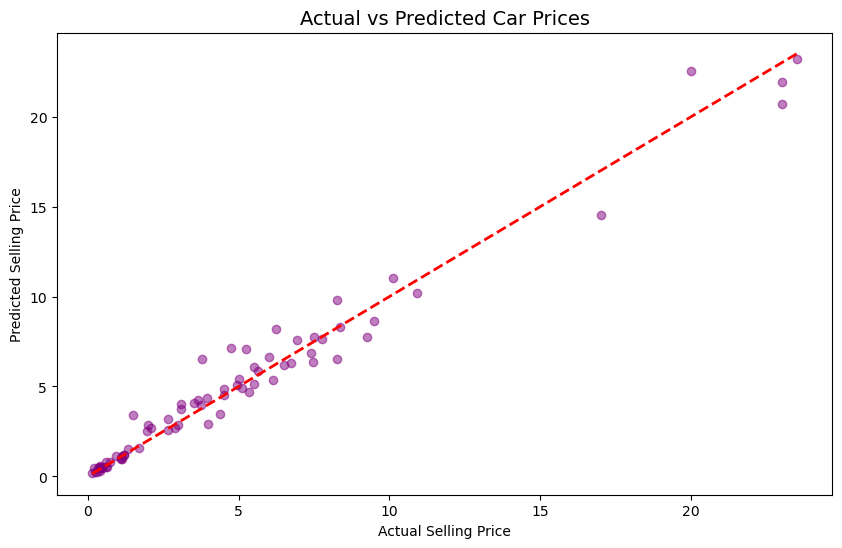

In [32]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, predictions, alpha=0.5, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')
plt.title('Actual vs Predicted Car Prices', fontsize=14)
plt.show()

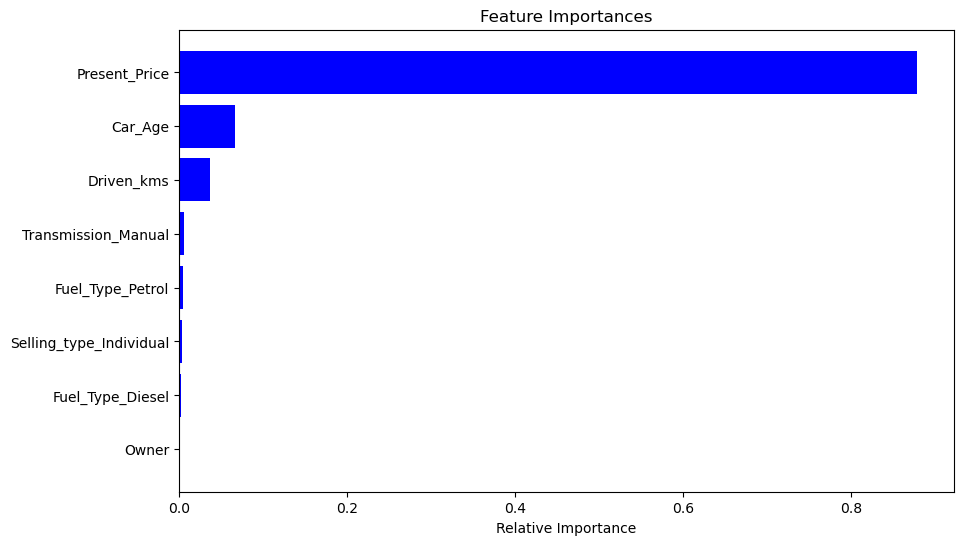

In [37]:
# Quick Feature Importance Visualization
importances =  model.feature_importances_
feat_names = X.columns
indices = np.argsort(importances)

plt.figure(figsize=(10,6))
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [feat_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

In [ ]:
def get_valid_input(prompt, input_type, valid_options=None):
    """Helper function to retry a specific input until it is valid."""
    while True:
        try:
            user_input = input(prompt)
            # Handle numeric types
            if input_type in [float, int]:
                value = input_type(user_input)
                # Basic logic check: prices and kms shouldn't be negative
                if value < 0:
                    print("Ooops, value cannot be negative, try again.")
                    continue
                return value
            
            # Handle categorical types (text)
            else:
                value = user_input.strip().capitalize()
                if valid_options and value not in valid_options:
                    print(f"Ooops, wrong input. Please choose from {valid_options}, try again.")
                    continue
                return value
                
        except ValueError:
            print("Ooops, wrong input. Please enter a number, try again.")

def predict_car_price():
    print("--- 🚗 Car Price Predictor 🚗 ---")
    
    # 1. Collect Inputs using the helper function
    present_price = get_valid_input("Enter Present Price of the car (in Lakhs): ", float)
    kms_driven = get_valid_input("Enter Kilometers Driven: ", int)
    owner = get_valid_input("Number of previous owners (0, 1, or 3): ", int)
    age = get_valid_input("How old is the car (in years)?: ", int)
    
    fuel_type = get_valid_input("Fuel Type (Petrol/Diesel/Cng): ", str, ['Petrol', 'Diesel', 'Cng'])
    seller_type = get_valid_input("Seller Type (Dealer/Indivisual): ", str, ['Dealer', 'Indivisual'])
    transmission = get_valid_input("Transmission (Manual/Automatic): ", str, ['Manual', 'Automatic'])

    # 2. Match the Encoding
    is_diesel = 1 if fuel_type == 'Diesel' else 0
    is_petrol = 1 if fuel_type == 'Petrol' else 0
    is_individual = 1 if seller_type == 'IndivisManual' else 0
    is_manual = 1 if transmission == 'Manual' else 0

    # 3. Create the input array
    custom_data = np.array([[present_price, kms_driven, owner, age, 
                             is_diesel, is_petrol, is_indivisual, is_manual]])

    # 4. Predict
    prediction = model.predict(custom_data)
    
    print(f"\n--- 💡 Prediction ---")
    print(f"The estimated Selling Price for this car is: {prediction[0]:.2f} Lakhs")

# Run the function
predict_car_price()